In [1]:
from pathlib import Path
import scanpy as sc
import pandas as pd

sc.settings.verbosity = 3
sc.settings.set_figure_params(
    dpi=100,
    dpi_save=600,
    facecolor="white",
    frameon=False,
    vector_friendly=True,
)

project_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast")

adata_path = project_dir / "results/processed/hemo_d1_10_revised_annotation.h5ad"
adata = sc.read_h5ad(adata_path)

source_key = "CellType_revised_short"   
new_key = "CellType_short"

rename_map = {
    "YS ExM": "YS Mes",
    "ECM ExM": "Adv Mes",
}

adata.obs[new_key] = adata.obs[source_key].astype(str).replace(rename_map)

print("Original:")
print(adata.obs[source_key].value_counts())

print("\nNew CellType_short:")
print(adata.obs[new_key].value_counts())

print("\nCheck remaining old labels in CellType_short:")
print(adata.obs[new_key].isin(["YS ExM", "ECM ExM"]).value_counts())

Original:
CellType_revised_short
Epi          22684
ECM ExM      14631
Epi trans    10567
Amn           5734
HE            4488
Blood/Ery     2963
Ambig.        1600
YS ExM        1469
Nasc Mes      1404
Trans ExM     1258
Endoderm       818
PGC            747
TE             135
Name: count, dtype: int64

New CellType_short:
CellType_short
Epi          22684
Adv Mes      14631
Epi trans    10567
Amn           5734
HE            4488
Blood/Ery     2963
Ambig.        1600
YS Mes        1469
Nasc Mes      1404
Trans ExM     1258
Endoderm       818
PGC            747
TE             135
Name: count, dtype: int64

Check remaining old labels in CellType_short:
CellType_short
False    68498
Name: count, dtype: int64


In [2]:
fig_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast/results/figures/033_hemo_rename_plot")
fig_dir.mkdir(parents=True, exist_ok=True)

sc.settings.figdir = str(fig_dir)

In [3]:
celltype_palette = {
    # epithelial / embryo
    "Epi": "#8C6BB1",
    "Epi trans": "#F1A340",
    "PS": "#E377C2",
    "Ambig.": "#7F7F7F",
    "Amn": "#AEC7E8",
    "TE": "#FDB462",
    "PGC": "#006400",

    # endoderm / hypoblast
    "Endoderm": "#999999",
    "Early Hypo": "#CC79A7",
    "Late Hypo": "#0072B2",
    "CDX2+ Hypo": "#E69F00",

    # mesoderm / ExM
    "Nasc Mes": "#BCBD22",
    "Emerg Mes": "#C49C94",
    "Adv Mes": "#8C564B",
    "Trans ExM": "#17BECF",
    "YS Mes": "#FF9896",

    # endothelial
    "HE": "#D55E00",
    "Art": "#66C2A5",
    "Vein": "#3288BD",

    # blood / erythroid / myeloid
    "Blood/Ery": "#D62728",
    "Ery": "#D62728",
    "EMP": "#FDBF6F",
    "Mk": "#984EA3",
    "Gran": "#F0E442",
}


In [4]:
import pandas as pd

def apply_alphabetical_palette(adata, key, palette):
    labels = sorted(adata.obs[key].astype(str).unique())

    missing = sorted(set(labels) - set(palette))
    if missing:
        raise ValueError(f"{key}: missing colors for {missing}")

    adata.obs[key] = pd.Categorical(
        adata.obs[key].astype(str),
        categories=labels,
        ordered=False,
    )

    adata.uns[f"{key}_colors"] = [palette[x] for x in labels]

    return pd.DataFrame({
        key: labels,
        "color": adata.uns[f"{key}_colors"],
    })

In [5]:
df_colors = apply_alphabetical_palette(
    adata,
    key="CellType_short",
    palette=celltype_palette,
)

df_colors

,CellType_short,color
0,Adv Mes,#8C564B
1,Ambig.,#7F7F7F
2,Amn,#AEC7E8
3,Blood/Ery,#D62728
4,Endoderm,#999999
5,Epi,#8C6BB1
6,Epi trans,#F1A340
7,HE,#D55E00
8,Nasc Mes,#BCBD22
9,PGC,#006400


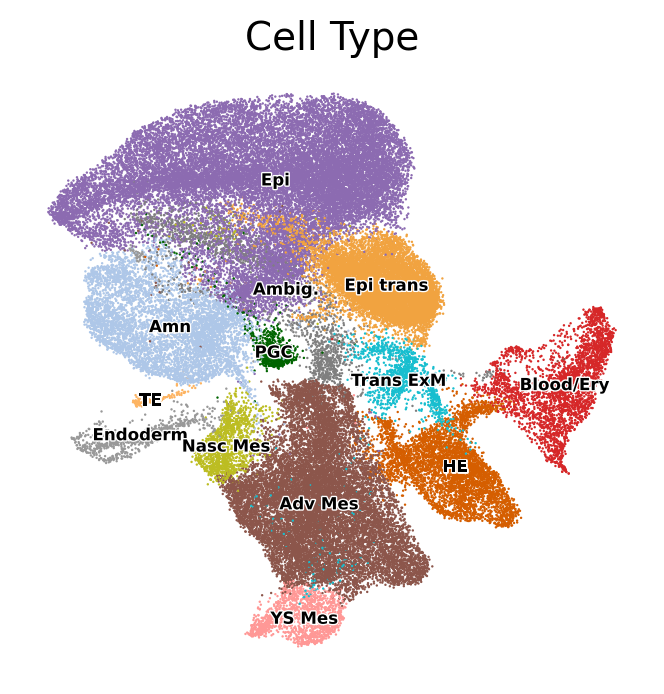

In [6]:
sc.pl.umap(adata, color='CellType_short', 
           frameon=False, legend_loc='on data', 
           legend_fontsize=6, legend_fontoutline=1, title='Cell Type', size=3,
           save='_basic_annotations.pdf')

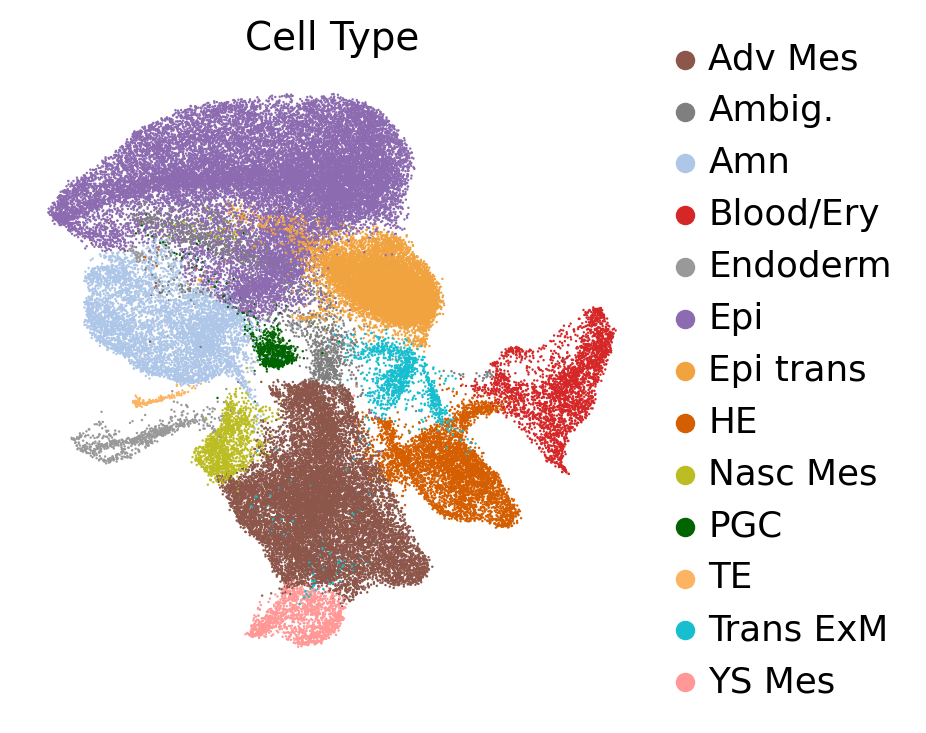

In [7]:
sc.pl.umap(adata, color='CellType_short', 
           frameon=False, title='Cell Type', size=3,
           save='_basic_annotations_legend_side.pdf')

In [8]:
marker_sets_revised_short = {
    "Nasc Mes": [
        "MESP1", "MIXL1", "DLL3", "LHX1", "APLNR"
    ],
    "Trans ExM": [
        "H19", "IGF2", "VIM", "COL3A1", "MDK"
    ],
    "Adv Mes": [
        "CDH11", "MRC2", "COL6A3", "HAND1", "COL4A2"
    ],
    "YS Mes": [
        "AQP1", "FRZB", "SLC9A3R1", "POSTN", "APOE"
    ],
    # "Endoderm": [
    #     "SOX17", "FOXA2", "APOA1", "APOA2", "TTR"
    # ],
    # "HE": [
    #     "KDR", "PECAM1", "CDH5", "ESAM", "RUNX1"
    # ],
    "Blood/Ery": [
        "HBE1", "HBZ", "HBG1", "GYPA", "KLF1"
    ],
}

In [6]:
adata_exm = adata[adata.obs['CellType_short'].isin(['Nasc Mes', 'Trans ExM', 'Adv Mes', 'YS Mes'])]

/tmp/ipykernel_4156922/2826404871.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_exm.obs[groupby_key] = pd.Categorical(


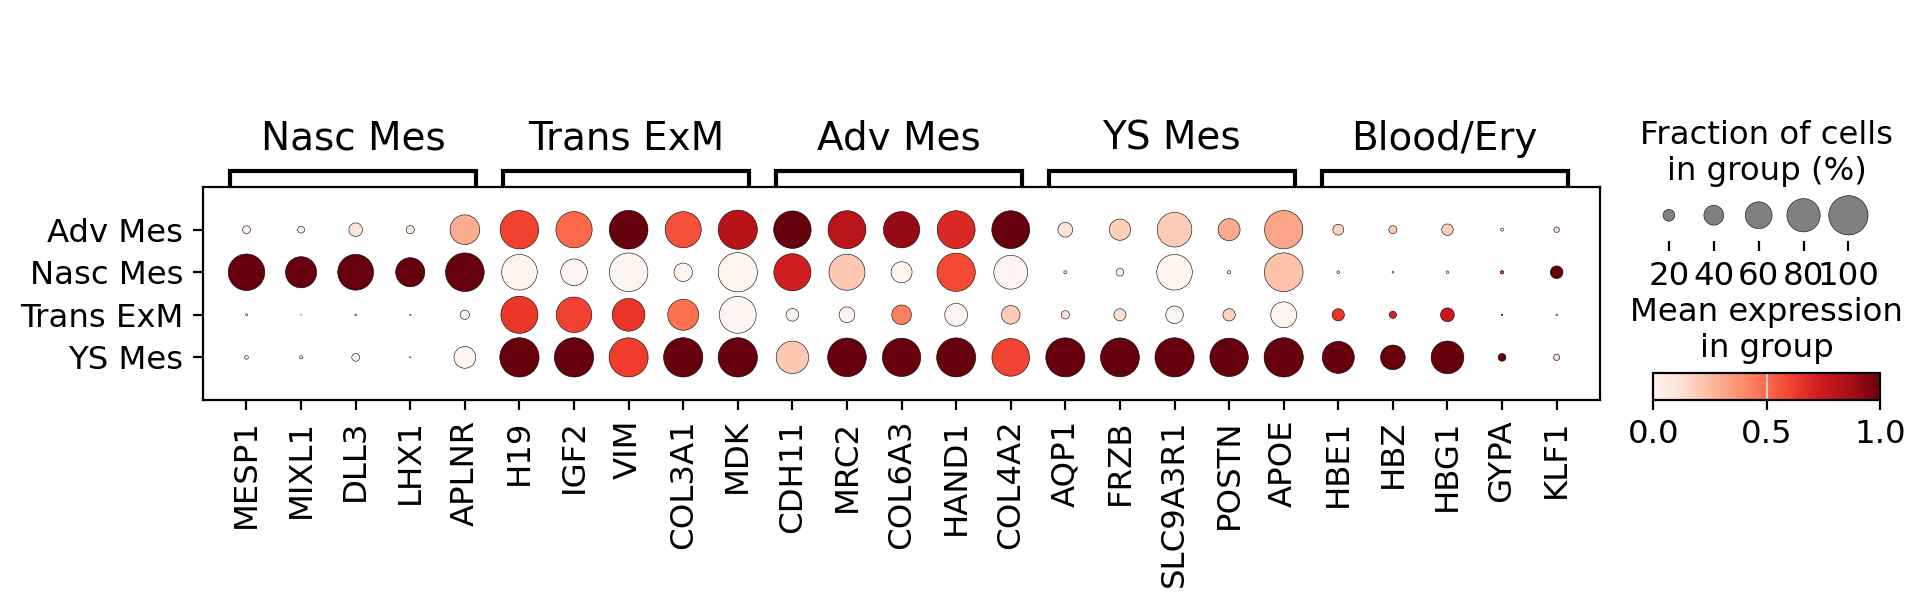

In [10]:
groupby_key = "CellType_short"

marker_sets_present = {
    group: [g for g in genes if g in adata_exm.var_names]
    for group, genes in marker_sets_revised_short.items()
}

adata_exm.obs[groupby_key] = pd.Categorical(
    adata_exm.obs[groupby_key],
    ordered=True,
)

sc.pl.dotplot(
    adata_exm,
    var_names=marker_sets_present,
    groupby=groupby_key,
    standard_scale="var",
    dendrogram=False,
    var_group_rotation=0,
    save='exm_marker.pdf'
)

In [12]:
marker_sets_revised_short = {
    "Nasc Mes": [
        "MESP1", "MIXL1", "DLL3", "LHX1", "APLNR"
    ],
    "Trans ExM": [
        "H19", "IGF2", "VIM", "COL3A1", "MDK"
    ],
    "Adv Mes": [
        "CDH11", "MRC2", "COL6A3", "HAND1", "COL4A2"
    ],
    "YS Mes": [
        "AQP1", "FRZB", "SLC9A3R1", "POSTN", "APOE"
    ],
    "Endoderm": [
        "SOX17", "FOXA2", "APOA1", "APOA2", "PDGFRA"
    ],
    "HE": [
        "KDR", "PECAM1", "CDH5", "ESAM", "RUNX1"
    ],
    "Blood/Ery": [
        "HBE1", "HBZ", "HBG1", "GYPA", "KLF1"
    ],
    "TE":["GATA3", "KRT7", "CDX2"]
}

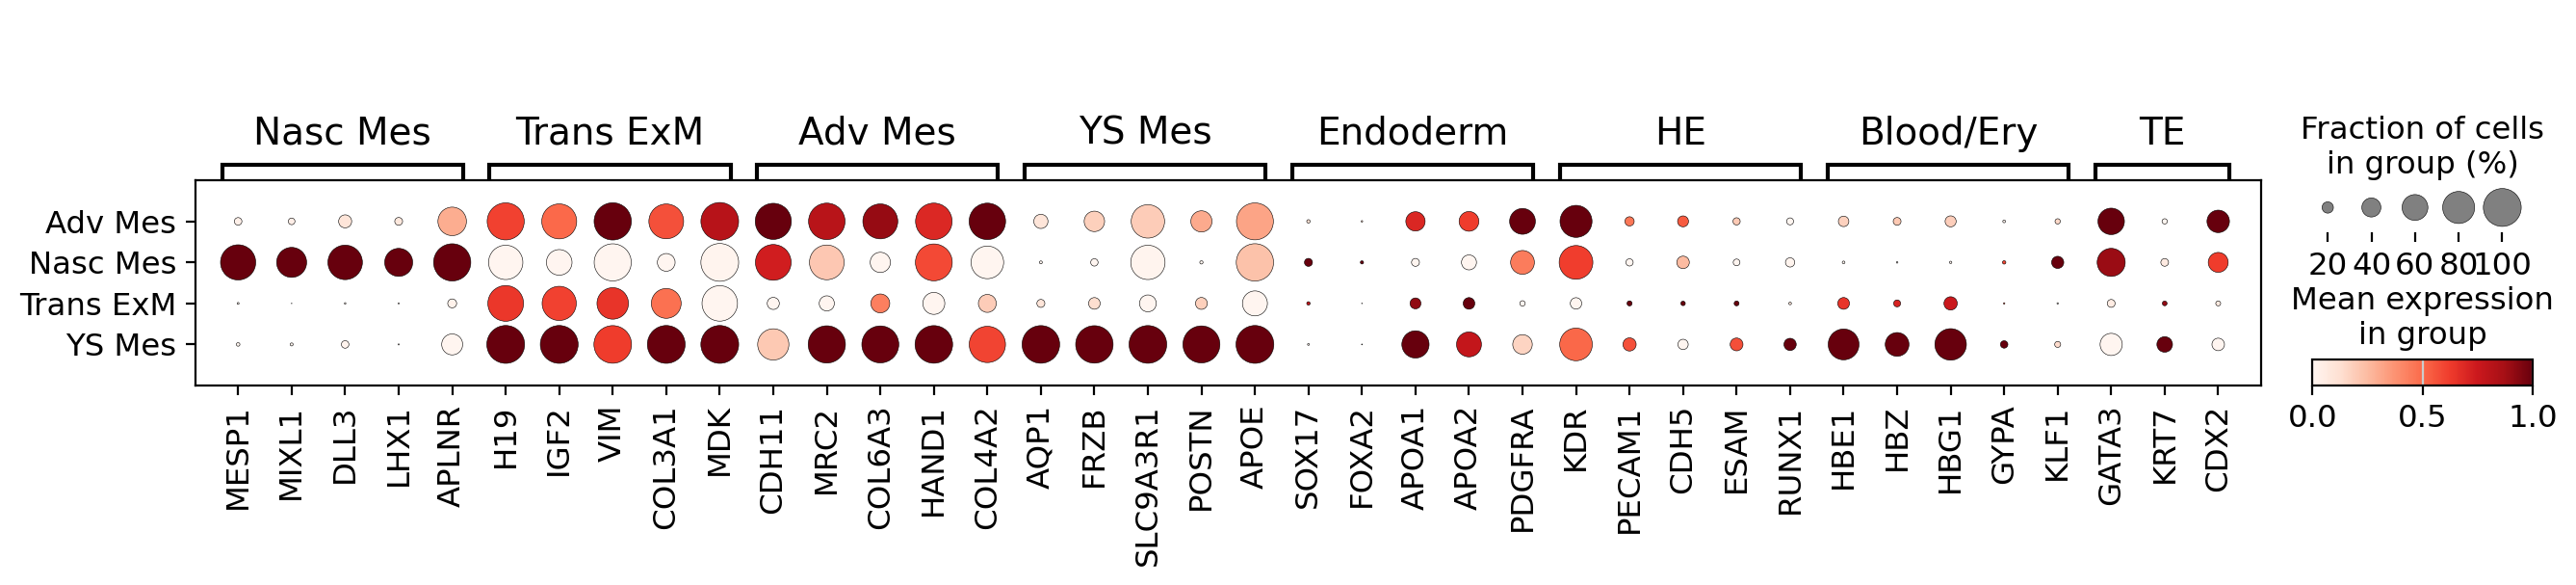

In [13]:
groupby_key = "CellType_short"

marker_sets_present = {
    group: [g for g in genes if g in adata_exm.var_names]
    for group, genes in marker_sets_revised_short.items()
}

adata_exm.obs[groupby_key] = pd.Categorical(
    adata_exm.obs[groupby_key],
    ordered=True,
)

sc.pl.dotplot(
    adata_exm,
    var_names=marker_sets_present,
    groupby=groupby_key,
    standard_scale="var",
    dendrogram=False,
    var_group_rotation=0,
    save='exm_marker_v2.pdf'
)

In [11]:
import pandas as pd

day_key = "day"              
celltype_key = "CellType_short"

assert day_key in adata.obs.columns, f"{day_key} not found in adata.obs"
assert celltype_key in adata.obs.columns, f"{celltype_key} not found in adata.obs"

df_frac = (
    adata.obs
    .groupby([day_key, celltype_key], observed=False)
    .size()
    .reset_index(name="n_cells")
)

df_frac["fraction"] = (
    df_frac["n_cells"] /
    df_frac.groupby(day_key)["n_cells"].transform("sum")
)

df_frac = df_frac.sort_values([day_key, celltype_key]).reset_index(drop=True)

df_frac

,day,CellType_short,n_cells,fraction
0,1,Adv Mes,0,0.000000
1,1,Ambig.,246,0.043075
2,1,Amn,0,0.000000
3,1,Blood/Ery,0,0.000000
4,1,Endoderm,0,0.000000
...,...,...,...,...
125,10,Nasc Mes,7,0.001860
126,10,PGC,7,0.001860
127,10,TE,36,0.009567
128,10,Trans ExM,111,0.029498


In [12]:
df_frac_wide = df_frac.pivot(
    index=day_key,
    columns=celltype_key,
    values="fraction"
).fillna(0)

df_frac_wide

CellType_short,Adv Mes,Ambig.,Amn,Blood/Ery,Endoderm,Epi,Epi trans,HE,Nasc Mes,PGC,TE,Trans ExM,YS Mes
day,,,,,,,,,,,,,
1,0.000000,0.043075,0.000000,0.000000,0.000000,0.898267,0.058659,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.001553,0.028186,0.019826,0.000000,0.000717,0.919742,0.027708,0.000239,0.001075,0.000955,0.000000,0.000000,0.000000
3,0.034348,0.020184,0.302939,0.000000,0.002656,0.600921,0.016112,0.003364,0.010092,0.008676,0.000000,0.000708,0.000000
4,0.309676,0.025596,0.058367,0.000000,0.011247,0.325383,0.028893,0.083964,0.130308,0.021330,0.001163,0.004072,0.000000
5,0.063557,0.017817,0.055977,0.000194,0.002786,0.177324,0.606349,0.033236,0.030969,0.009524,0.001037,0.001231,0.000000
6,0.480950,0.025843,0.038100,0.006841,0.008646,0.142993,0.017767,0.217387,0.012637,0.037530,0.000855,0.010451,0.000000
7,0.592254,0.025004,0.041510,0.012093,0.061285,0.085471,0.027292,0.069619,0.007027,0.003105,0.000163,0.047230,0.027946
8,0.531201,0.024216,0.008382,0.088792,0.035703,0.000621,0.001863,0.119839,0.001552,0.001242,0.000000,0.099038,0.087550
9,0.214034,0.013418,0.222173,0.235372,0.012538,0.000440,0.003960,0.069072,0.000000,0.001760,0.014738,0.084690,0.127805


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

celltype_key = "CellType_short"

adata.obs[celltype_key] = adata.obs[celltype_key].astype("category")

color_dict = dict(
    zip(
        adata.obs[celltype_key].cat.categories.astype(str),
        adata.uns[f"{celltype_key}_colors"]
    )
)

missing = set(df_frac.columns.astype(str)) - set(color_dict.keys())
extra = set(color_dict.keys()) - set(df_frac.columns.astype(str))

print("Missing in color_dict:", missing)
print("Extra in color_dict:", extra)

Missing in color_dict: {'CellType_short', 'day', 'fraction', 'n_cells'}
Extra in color_dict: {'Nasc Mes', 'TE', 'Blood/Ery', 'Ambig.', 'Epi', 'PGC', 'Trans ExM', 'YS Mes', 'Epi trans', 'Adv Mes', 'Amn', 'HE', 'Endoderm'}


In [33]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def plot_stacked_bar_with_ribbons(
    frac_df,
    title,
    ylabel="Fraction of cells",
    figsize=(5.0, 3.2),
    save_prefix=None,
    width=0.72,
    alpha_bar=0.95,
    alpha_ribbon=0.28,
    color_dict=None,
    fig_dir=None,
    reverse_stack=False,
):
    """
    Stacked bar plot with ribbons.

    frac_df:
        rows = days / samples
        columns = cell types
        values = fractions, each row should sum to 1

    reverse_stack:
        If True, only reverse the vertical stacked order of bars/ribbons.
        Legend order is kept the same as the original frac_df column order.
    """

    frac_df = frac_df.copy().fillna(0)
    frac_df.columns = frac_df.columns.astype(str)

    x = np.arange(frac_df.shape[0])

    # Original order controls legend
    legend_groups = list(frac_df.columns)

    # Plot order controls vertical stacking
    plot_groups = legend_groups[::-1] if reverse_stack else legend_groups

    if color_dict is None:
        cmap = plt.get_cmap("tab20")
        colors = {group: cmap(i % cmap.N) for i, group in enumerate(legend_groups)}
    else:
        missing = [g for g in legend_groups if g not in color_dict]
        if len(missing) > 0:
            raise ValueError(f"These groups are missing from color_dict: {missing}")
        colors = {group: color_dict[group] for group in legend_groups}

    # Reorder only for plotting
    plot_df = frac_df[plot_groups]

    fig, ax = plt.subplots(figsize=figsize)

    # cumulative boundaries based on plot order
    bottoms = plot_df.cumsum(axis=1) - plot_df
    tops = plot_df.cumsum(axis=1)

    # ribbons behind bars
    for group in plot_groups:
        color = colors[group]

        for i in range(len(x) - 1):
            x_left = x[i] + width / 2
            x_right = x[i + 1] - width / 2

            y0_left = bottoms.iloc[i][group]
            y1_left = tops.iloc[i][group]
            y0_right = bottoms.iloc[i + 1][group]
            y1_right = tops.iloc[i + 1][group]

            ax.fill(
                [x_left, x_right, x_right, x_left],
                [y0_left, y0_right, y1_right, y1_left],
                color=color,
                alpha=alpha_ribbon,
                linewidth=0,
                zorder=1,
            )

    # stacked bars
    bottom = np.zeros(plot_df.shape[0])

    bar_handles = {}

    for group in plot_groups:
        values = plot_df[group].values
        color = colors[group]

        bar = ax.bar(
            x,
            values,
            bottom=bottom,
            width=width,
            color=color,
            edgecolor="black",
            linewidth=0.7,
            alpha=alpha_bar,
            label=group,
            zorder=2,
        )

        bar_handles[group] = bar[0]
        bottom += values

    ax.set_xticks(x)
    ax.set_xticklabels(frac_df.index, rotation=0)

    ax.set_ylim(0, 1)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.grid(False)
    ax.set_facecolor("white")
    fig.patch.set_facecolor("white")

    # Legend keeps original frac_df column order
    ax.legend(
        [bar_handles[g] for g in legend_groups],
        legend_groups,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        fontsize=8,
        title=None,
    )

    plt.tight_layout()

    if save_prefix is not None:
        if fig_dir is None:
            fig.savefig(
                f"{save_prefix}.pdf",
                bbox_inches="tight",
                facecolor="white",
            )
        else:
            fig.savefig(
                Path(fig_dir) / f"{save_prefix}.pdf",
                bbox_inches="tight",
                facecolor="white",
            )

    plt.show()

    return plot_df

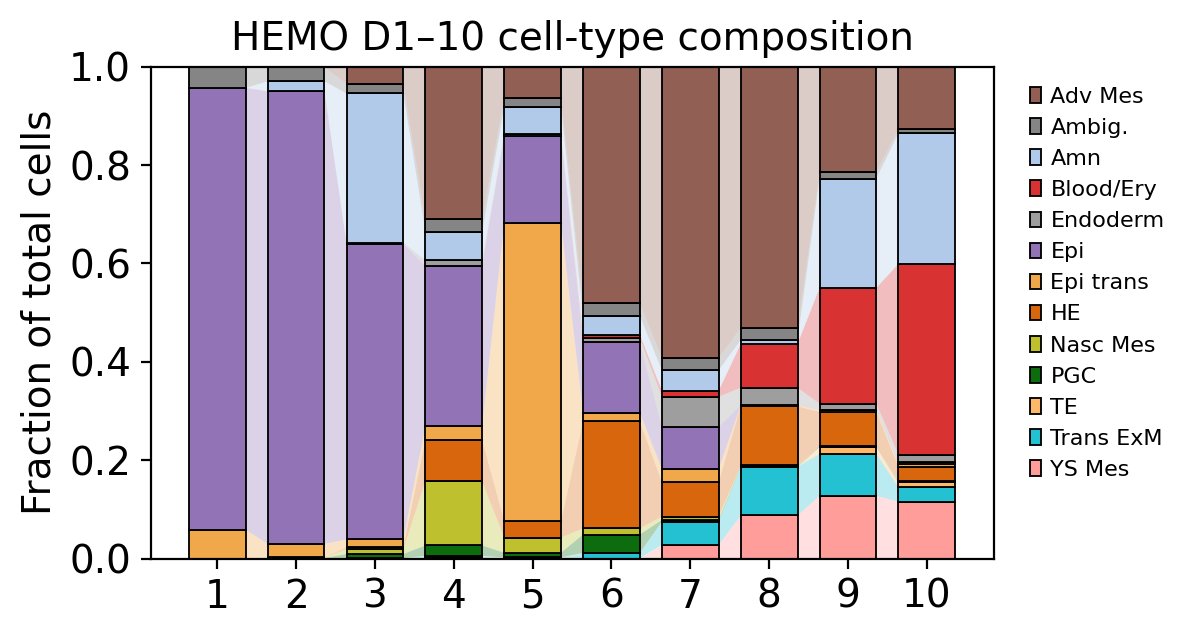

In [34]:
plot_df_reversed = plot_stacked_bar_with_ribbons(
    df_frac_wide,
    title="HEMO D1–10 cell-type composition",
    ylabel="Fraction of total cells",
    figsize=(6.2, 3.4),
    save_prefix="barplot_hemo_d1_10_celltype_proportion_reversed",
    width=0.72,
    alpha_ribbon=0.30,
    color_dict=color_dict,
    fig_dir=fig_dir,
    reverse_stack=True,
)

In [16]:
adata.write_h5ad(
    "/mnt/yiming/nfs_share/projects/hypoblast/results/processed/hemo_d1_10_revised_annotation.h5ad"
)

In [17]:
marker_sets_revised_short_v5 = {
    "Epi": [
        "POU5F1", "NANOG", "SOX2", "TDGF1", "DPPA5"
    ],
    "Epi trans": [
        "XACT", "ESRG", "L1TD1", "TRIM71", "JARID2"
    ],
    "Ambig.": [
        "SOX4", "WSB1", "SLC38A2", "RND3", "TLE4"
    ],
    "Nasc Mes": [
        "MESP1", "MIXL1", "DLL3", "LHX1", "APLNR"
    ],
    "Trans ExM": [
        "H19", "IGF2", "VIM", "COL3A1", "MDK"
    ],
    "Adv Mes": [
        "CDH11", "MRC2", "COL6A3", "HAND1", "COL4A2"
    ],
    "YS Mes": [
        "AQP1", "FRZB", "SLC9A3R1", "POSTN", "APOE"
    ],
    "Endoderm": [
        "SOX17", "FOXA2", "APOA1", "APOA2", "TTR"
    ],
    "Amn": [
        "GABRP", "TFAP2A", "KRT19", "CLDN4", "DSP"
    ],
    "PGC": [
        "TFAP2C", "PRDM1", "PRDM14", "KIT", "DPPA3"
    ],
    "TE": [
        "GATA3", "KRT7", "CDX2", "TEAD4", "KRT8"
    ],
    "HE": [
        "KDR", "PECAM1", "CDH5", "ESAM", "RUNX1"
    ],
    "Blood/Ery": [
        "HBE1", "HBZ", "HBG1", "GYPA", "KLF1"
    ],
}

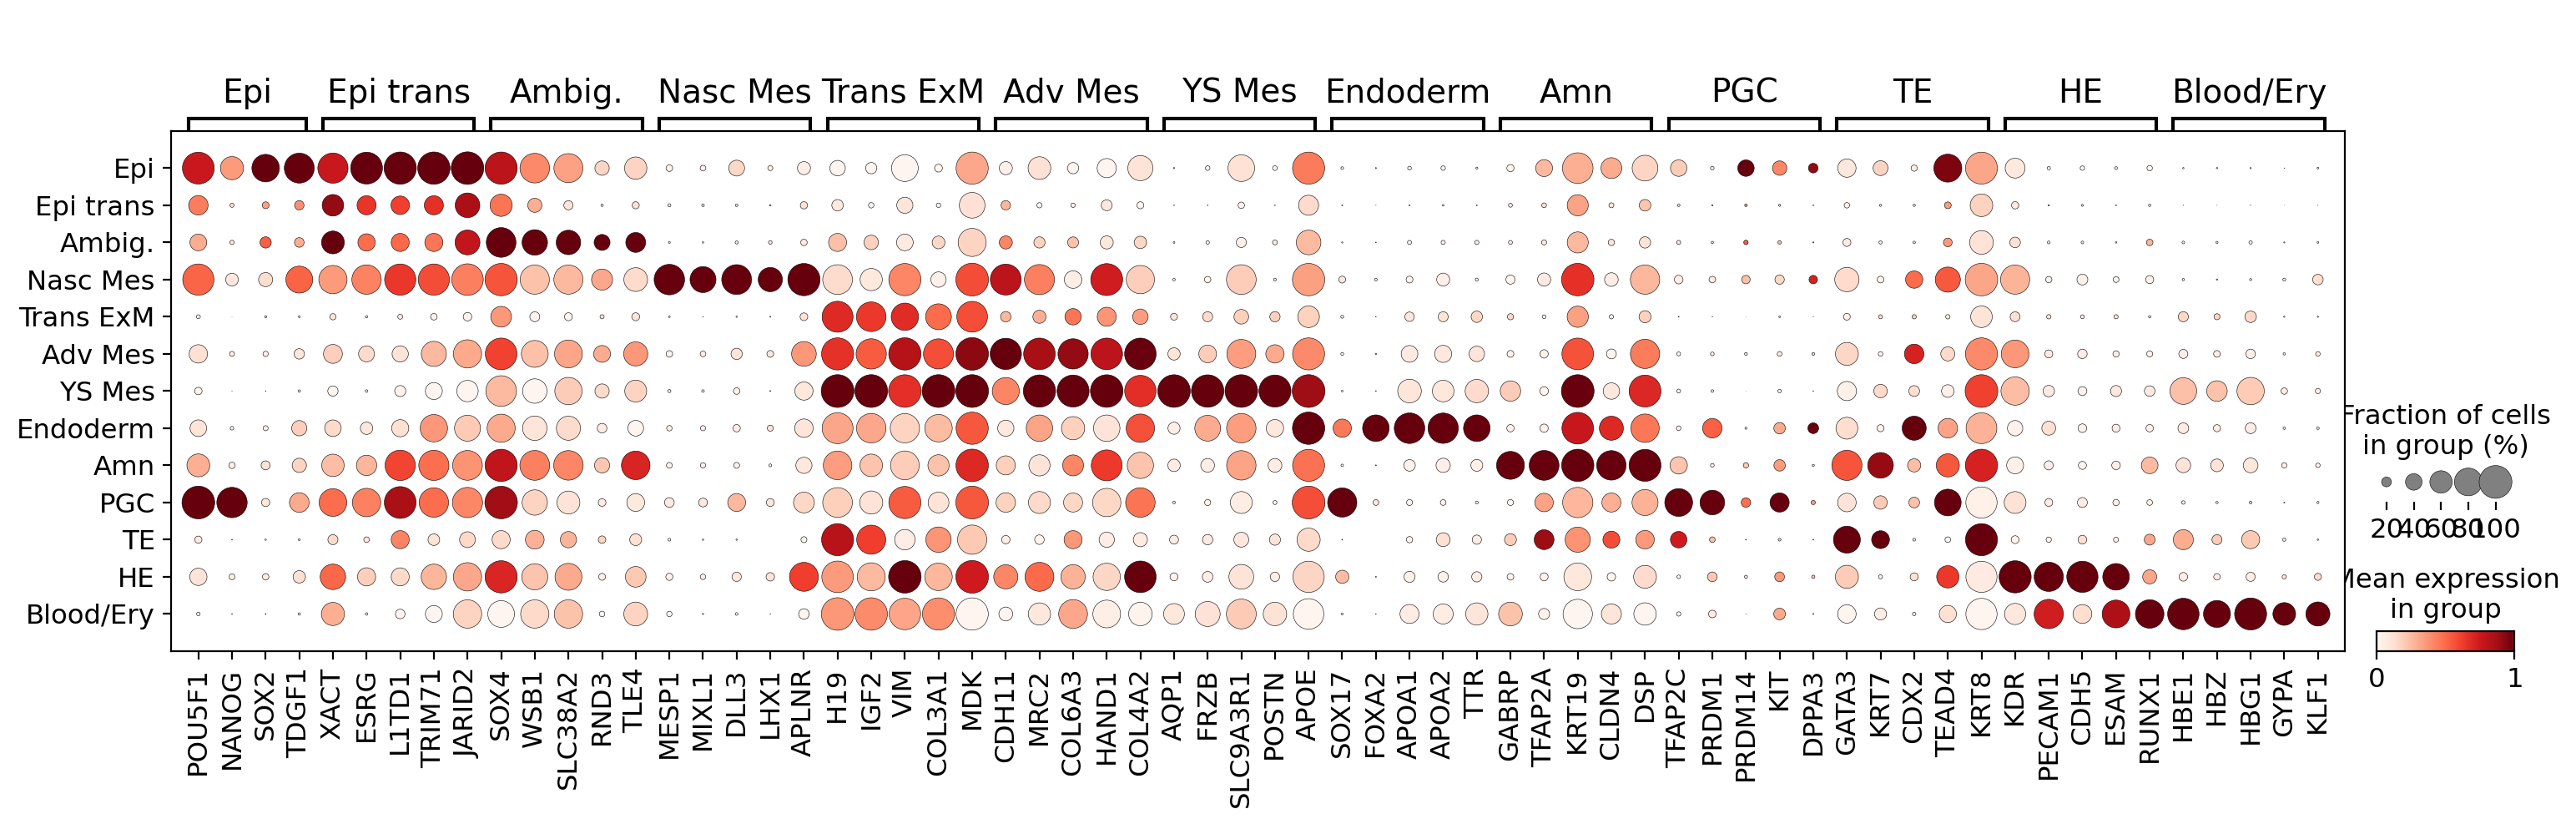

In [18]:
groupby_key = "CellType_short"

short_order = [
    "Epi",
    "Epi trans",
    "Ambig.",
    "Nasc Mes",
    "Trans ExM",
    "Adv Mes",
    "YS Mes",
    "Endoderm",
    "Amn",
    "PGC",
    "TE",
    "HE",
    "Blood/Ery",
]

marker_sets_present = {
    group: [g for g in genes if g in adata.var_names]
    for group, genes in marker_sets_revised_short_v5.items()
}

adata.obs[groupby_key] = pd.Categorical(
    adata.obs[groupby_key],
    categories=short_order,
    ordered=True,
)

dp = sc.pl.dotplot(
    adata,
    var_names=marker_sets_present,
    groupby=groupby_key,
    standard_scale="var",
    dendrogram=False,
    var_group_rotation=0,
    return_fig=True,
)

dp.make_figure()
dp.fig.set_size_inches(18, 5)

In [19]:
dp.fig.savefig(
    "/mnt/yiming/nfs_share/projects/hypoblast/results/figures/033_hemo_rename_plot/hemo_d1_10_revised_annotation_marker_dotplot.pdf",
    bbox_inches="tight",
    facecolor="white",
)

plt.close(dp.fig)

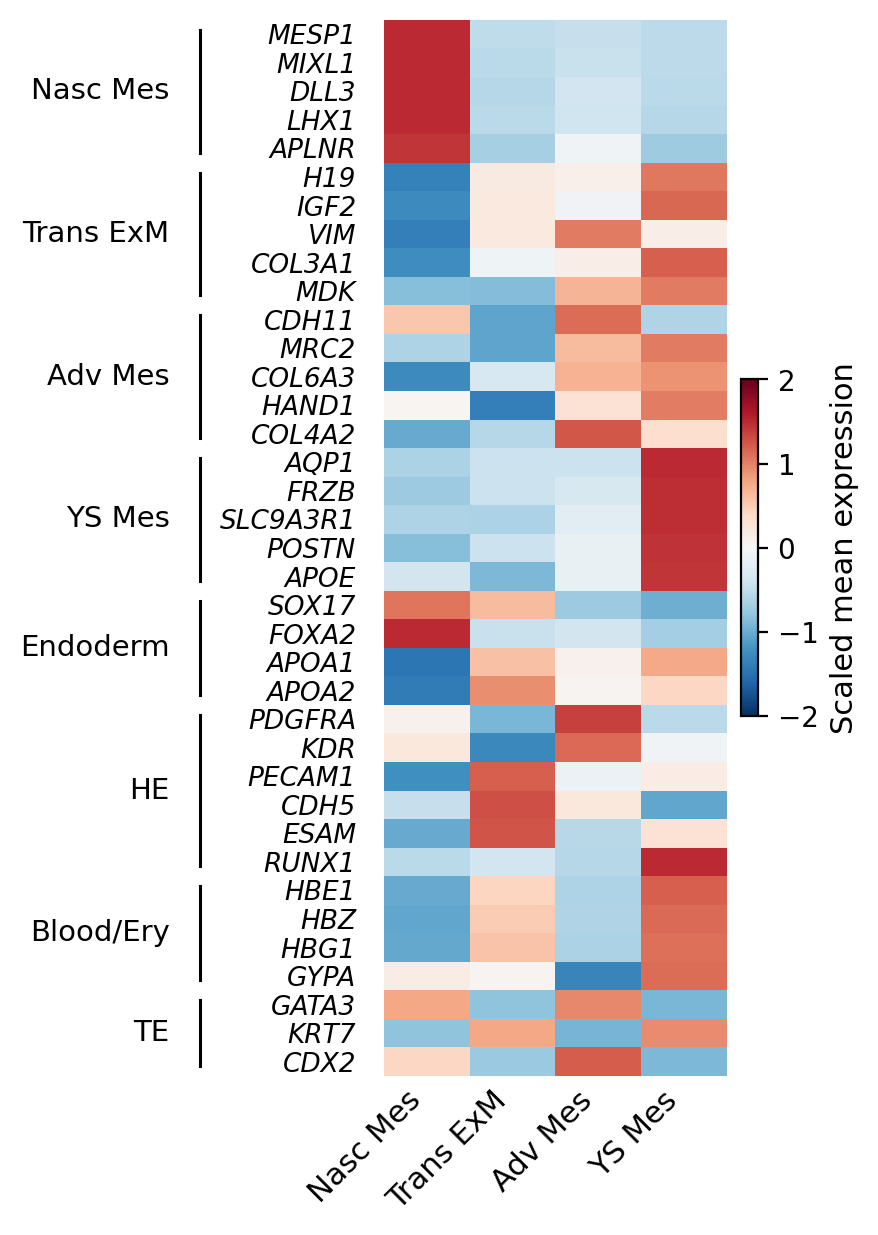

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy import sparse

# ------------------------------------------------------------
# Marker groups
# ------------------------------------------------------------
marker_groups = {
    "Nasc Mes": ["MESP1", "MIXL1", "DLL3", "LHX1", "APLNR"],
    "Trans ExM": ["H19", "IGF2", "VIM", "COL3A1", "MDK"],
    "Adv Mes": ["CDH11", "MRC2", "COL6A3", "HAND1", "COL4A2"],
    "YS Mes": ["AQP1", "FRZB", "SLC9A3R1", "POSTN", "APOE"],
    "Endoderm": ["SOX17", "FOXA2", "APOA1", "APOA2"],
    "HE": ["PDGFRA", "KDR", "PECAM1", "CDH5", "ESAM", "RUNX1"],
    "Blood/Ery": ["HBE1", "HBZ", "HBG1", "GYPA"],
    "TE": ["GATA3", "KRT7", "CDX2"],
}

celltype_order = ["Nasc Mes", "Trans ExM", "Adv Mes", "YS Mes"]

# ------------------------------------------------------------
# Use raw if available
# ------------------------------------------------------------
if adata_exm.raw is not None:
    adata_use = adata_exm.raw.to_adata()
else:
    adata_use = adata_exm.copy()

# keep available genes
genes = []
gene_groups_flat = []
for group, gs in marker_groups.items():
    for g in gs:
        if g in adata_use.var_names:
            genes.append(g)
            gene_groups_flat.append(group)
        else:
            print(f"Missing gene: {g}")

adata_use = adata_use[:, genes].copy()

# ------------------------------------------------------------
# Mean expression per cell type
# ------------------------------------------------------------
mean_expr = pd.DataFrame(index=genes, columns=celltype_order, dtype=float)

for ct in celltype_order:
    idx = adata_use.obs["CellType_short"].astype(str) == ct
    X = adata_use[idx, genes].X

    if sparse.issparse(X):
        vals = np.asarray(X.mean(axis=0)).ravel()
    else:
        vals = X.mean(axis=0)

    mean_expr.loc[:, ct] = vals

# ------------------------------------------------------------
# Row-wise z-score
# ------------------------------------------------------------
mat_z = mean_expr.copy()
mat_z = mat_z.sub(mat_z.mean(axis=1), axis=0)
mat_z = mat_z.div(mat_z.std(axis=1).replace(0, np.nan), axis=0)
mat_z = mat_z.fillna(0)
mat_z = mat_z.clip(-2, 2)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.2, 6.6))

im = ax.imshow(
    mat_z.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    interpolation="nearest",
)

# x axis
ax.set_xticks(np.arange(len(celltype_order)))
ax.set_xticklabels(
    celltype_order,
    rotation=45,
    ha="right",
    va="top",
    fontsize=11,
)
ax.xaxis.tick_bottom()

# y axis genes
ax.set_yticks(np.arange(len(genes)))
ax.set_yticklabels(
    genes,
    fontsize=9.5,
    fontstyle="italic",
)

# keep gene names close to heatmap
ax.tick_params(axis="y", length=0, pad=10)
ax.tick_params(axis="x", length=0)

ax.set_xlabel("")
ax.set_ylabel("")

ax.grid(False)
ax.minorticks_off()

for spine in ax.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------
# Group labels + vertical bracket line
# ------------------------------------------------------------
group_start = 0

# 竖线再往左，并让 group label 也相应左移
line_x = -2.65
group_label_x = -3.00

for group, gs in marker_groups.items():
    available = [g for g in gs if g in genes]
    if len(available) == 0:
        continue

    group_end = group_start + len(available) - 1
    y_mid = (group_start + group_end) / 2

    ax.plot(
        [line_x, line_x],
        [group_start - 0.15, group_end + 0.15],
        color="black",
        linewidth=1.1,
        clip_on=False,
        zorder=10,
    )

    ax.text(
        group_label_x,
        y_mid,
        group,
        ha="right",
        va="center",
        fontsize=10.5,
        clip_on=False,
    )

    group_start += len(available)

# keep heatmap limits
ax.set_xlim(-0.5, len(celltype_order) - 0.5)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------
cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.045,
    pad=0.04,
)
cbar.set_label("Scaled mean expression", fontsize=11)
cbar.ax.tick_params(labelsize=10)

# more compact left space
plt.subplots_adjust(
    left=0.42,
    right=0.78,
    top=0.98,
    bottom=0.18,
)

# optional save
fig.savefig(fig_dir / "exm_marker_grouped_heatmap.pdf", bbox_inches="tight")
# fig.savefig(fig_dir / "exm_marker_grouped_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

Using adata.X
Missing gene: VAMP7
Missing gene: CYBB

Number of available marker genes: 38

Cell types included:
Nasc Mes: 1,404 cells
Trans ExM: 1,258 cells
Adv Mes: 14,631 cells
YS Mes: 1,469 cells


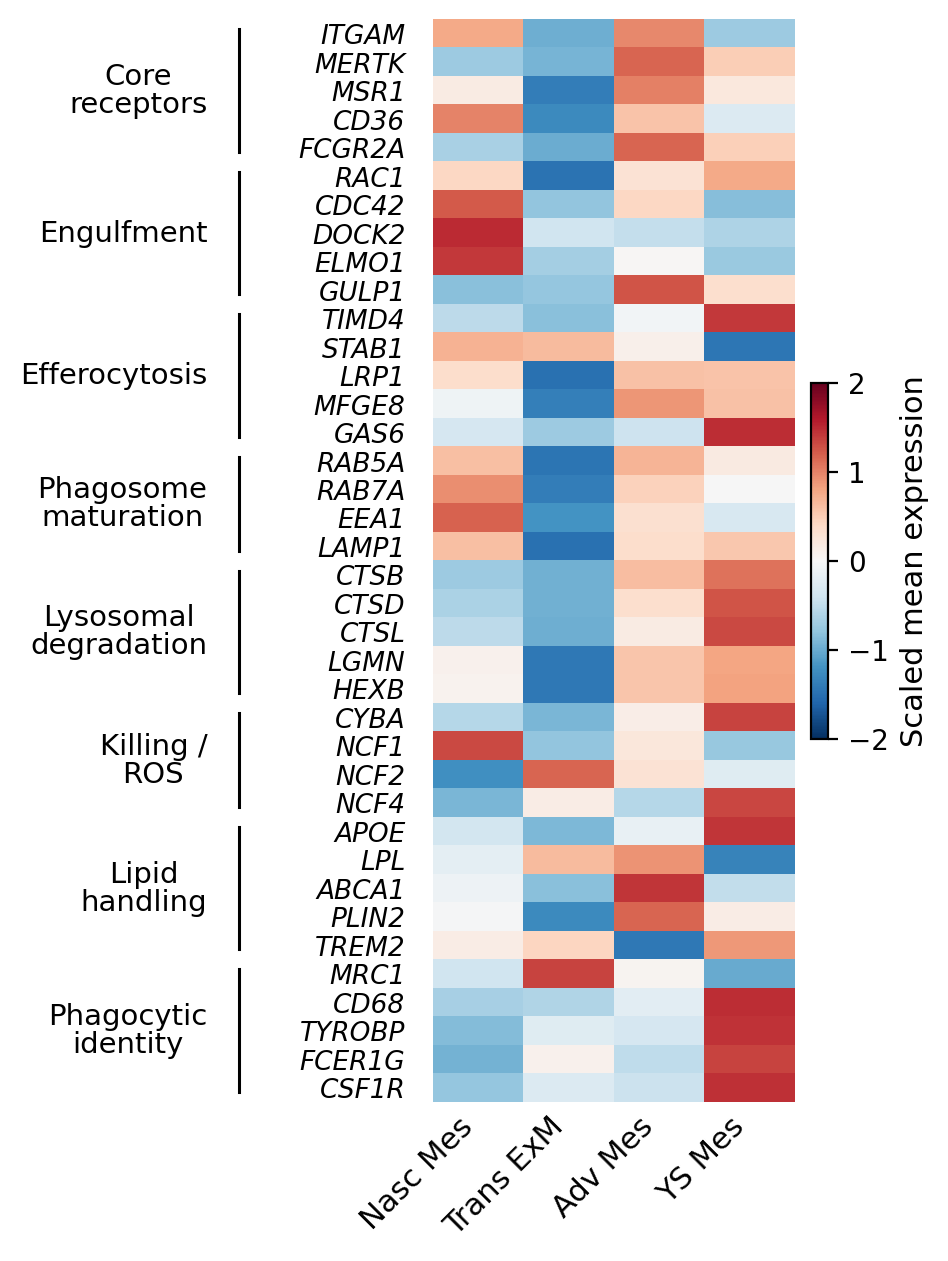

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

# ------------------------------------------------------------
# Marker groups
# ------------------------------------------------------------
marker_groups = {
    "Core receptors": ["ITGAM", "MERTK", "MSR1", "CD36", "FCGR2A"],
    "Engulfment": ["RAC1", "CDC42", "DOCK2", "ELMO1", "GULP1"],
    "Efferocytosis": ["TIMD4", "STAB1", "LRP1", "MFGE8", "GAS6"],
    "Phagosome maturation": ["RAB5A", "RAB7A", "EEA1", "LAMP1", "VAMP7"],
    "Lysosomal degradation": ["CTSB", "CTSD", "CTSL", "LGMN", "HEXB"],
    "Killing / ROS": ["CYBA", "CYBB", "NCF1", "NCF2", "NCF4"],
    "Lipid handling": ["APOE", "LPL", "ABCA1", "PLIN2", "TREM2"],
    "Phagocytic identity": ["MRC1", "CD68", "TYROBP", "FCER1G", "CSF1R"],
}

celltype_order = ["Nasc Mes", "Trans ExM", "Adv Mes", "YS Mes"]
# celltype_order = adata.obs['CellType_short'].unique()

# ------------------------------------------------------------
# Display labels for marker groups
# ------------------------------------------------------------
group_label_map = {
    "Core receptors": "Core\nreceptors",
    "Engulfment": "Engulfment",
    "Efferocytosis": "Efferocytosis",
    "Phagosome maturation": "Phagosome\nmaturation",
    "Lysosomal degradation": "Lysosomal\ndegradation",
    "Killing / ROS": "Killing /\nROS",
    "Lipid handling": "Lipid\nhandling",
    "Phagocytic identity": "Phagocytic\nidentity",
}

# ------------------------------------------------------------
# Use raw if available
# ------------------------------------------------------------
if adata.raw is not None:
    adata_use = adata.raw.to_adata()
    print("Using adata.raw")
else:
    adata_use = adata.copy()
    print("Using adata.X")

# Ensure unique gene names
if not adata_use.var_names.is_unique:
    print("var_names are not unique. Making them unique...")
    adata_use.var_names_make_unique()

# ------------------------------------------------------------
# Keep available genes without duplication
# ------------------------------------------------------------
genes = []
gene_groups_flat = []

for group, gs in marker_groups.items():
    for gene in gs:
        if gene in adata_use.var_names:
            if gene not in genes:
                genes.append(gene)
                gene_groups_flat.append(group)
        else:
            print(f"Missing gene: {gene}")

if len(genes) == 0:
    raise ValueError("None of the marker genes were found in adata_use.var_names.")

adata_use = adata_use[:, genes].copy()

print(f"\nNumber of available marker genes: {len(genes)}")

# ------------------------------------------------------------
# Keep only cell types present in the dataset
# ------------------------------------------------------------
celltype_key = "CellType_short"

celltype_series = (
    adata_use.obs[celltype_key]
    .astype(str)
    .str.strip()
)

celltype_counts = celltype_series.value_counts()

missing_celltypes = [
    ct for ct in celltype_order
    if celltype_counts.get(ct, 0) == 0
]

celltype_order = [
    ct for ct in celltype_order
    if celltype_counts.get(ct, 0) > 0
]

print("\nCell types included:")
for ct in celltype_order:
    print(f"{ct}: {celltype_counts[ct]:,} cells")

if missing_celltypes:
    print("\nCell types not found:")
    print(missing_celltypes)

if len(celltype_order) == 0:
    raise ValueError(
        f"None of the requested cell types were found in adata.obs['{celltype_key}']."
    )

# ------------------------------------------------------------
# Mean expression per cell type
# ------------------------------------------------------------
mean_expr = pd.DataFrame(
    index=genes,
    columns=celltype_order,
    dtype=float,
)

for ct in celltype_order:
    idx = celltype_series == ct
    n_cells = int(idx.sum())

    if n_cells == 0:
        continue

    X = adata_use[idx, genes].X

    if sparse.issparse(X):
        vals = np.asarray(X.mean(axis=0)).ravel()
    else:
        vals = np.asarray(X).mean(axis=0)

    mean_expr.loc[:, ct] = vals

# ------------------------------------------------------------
# Row-wise z-score
# ------------------------------------------------------------
mat_z = mean_expr.copy()

mat_z = mat_z.sub(
    mat_z.mean(axis=1),
    axis=0,
)

mat_z = mat_z.div(
    mat_z.std(axis=1).replace(0, np.nan),
    axis=0,
)

mat_z = mat_z.fillna(0)
mat_z = mat_z.clip(-2, 2)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(5.2, 6.6)
)

im = ax.imshow(
    mat_z.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    interpolation="nearest",
)

# ------------------------------------------------------------
# X axis
# ------------------------------------------------------------
ax.set_xticks(np.arange(len(celltype_order)))

ax.set_xticklabels(
    celltype_order,
    rotation=45,
    ha="right",
    va="top",
    fontsize=11,
)

ax.xaxis.tick_bottom()
ax.tick_params(
    axis="x",
    length=0,
)

# ------------------------------------------------------------
# Y axis
# ------------------------------------------------------------
ax.set_yticks(np.arange(len(genes)))

ax.set_yticklabels(
    genes,
    fontsize=9.5,
    fontstyle="italic",
)

ax.tick_params(
    axis="y",
    length=0,
    pad=10,
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.grid(False)
ax.minorticks_off()

for spine in ax.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------
# Group labels and vertical bracket lines
# ------------------------------------------------------------
group_start = 0

line_x = -2.65
group_label_x = -3.00

for group, gs in marker_groups.items():

    available = [
        gene for gene in gs
        if gene in genes
    ]

    if len(available) == 0:
        continue

    group_end = group_start + len(available) - 1
    y_mid = (group_start + group_end) / 2

    # Vertical bracket line
    ax.plot(
        [line_x, line_x],
        [group_start - 0.15, group_end + 0.15],
        color="black",
        linewidth=1.1,
        clip_on=False,
        zorder=10,
    )

    # Group label
    ax.text(
        group_label_x,
        y_mid,
        group_label_map.get(group, group),
        ha="right",
        va="center",
        fontsize=10.5,
        linespacing=1.0,
        multialignment="center",
        clip_on=False,
    )

    group_start += len(available)

# Keep heatmap limits
ax.set_xlim(
    -0.5,
    len(celltype_order) - 0.5,
)

# ------------------------------------------------------------
# Colorbar
# ------------------------------------------------------------
cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.045,
    pad=0.04,
)

cbar.set_label(
    "Scaled mean expression",
    fontsize=11,
)

cbar.ax.tick_params(
    labelsize=10,
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
plt.subplots_adjust(
    left=0.4,
    right=0.78,
    top=0.98,
    bottom=0.16,
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
fig.savefig(
    fig_dir / "phago_marker_grouped_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

In [ ]:
emt_genes = ['EGF', 'EGFR', 'STAT3', 'MAPK1', 
             'TGFB1', 'TGFBR1', 'TNF', 'TNFRSF1A', 
            'NFKB1', 'ZEB1', 'ZEB2', 'TWIST1', 'SNAI1', 'SNAI2', 
            'PRRX1', 'FOXC2', 'SOX4', 'SOX9', 
            'VIM', 'CDH2', 'FN1', 'MMP2', 'MMP9', 'LOX', 'TGM2']
sc.tl.score_genes(adata, emt_genes, score_name='EMT')

wnt_genes = ['WNT1', 'WNT2', 'WNT3', 'WNT3A', 'WNT4', 'WNT5A', 'WNT7A', 'WNT8A', 'WNT11',  
             'FZD1', 'FZD2', 'FZD3', 'FZD4', 'FZD5', 'FZD6', 'FZD7', 'FZD8', 'FZD9', 'FZD10',  
             'LRP5', 'LRP6', 'DVL1', 'DVL2', 'DVL3',  
             'AXIN1', 'AXIN2', 'APC', 'GSK3B', 'CTNNB1', 'TCF7', 'TCF7L1', 'TCF7L2', 'LEF1'] 
sc.tl.score_genes(adata, wnt_genes, score_name='WNT')

hedgehog_genes = ['SHH', 'IHH', 'DHH',  
                 'PTCH1', 'PTCH2', 'SMO',  
                 'GLI1', 'GLI2', 'GLI3',  
                 'SUFU', 'HHIP']  
sc.tl.score_genes(adata, hedgehog_genes, score_name='hedgehog')

tgf_bmp_genes = ['TGFB1', 'TGFB2', 'TGFB3',  
                'BMP2', 'BMP4', 'BMP7', 'BMP9',  
                'SMAD1', 'SMAD2', 'SMAD3', 'SMAD4', 'SMAD5', 'SMAD9',  
                'TGFBR1', 'TGFBR2', 'BMPR1A', 'BMPR1B', 'BMPR2',  
                'NOG', 'CHRD', 'GREM1', 'FST']  
sc.tl.score_genes(adata, tgf_bmp_genes, score_name='TGF/BMP')

notch_genes = ['NOTCH1', 'NOTCH2', 'NOTCH3', 'NOTCH4',  
              'DLL1', 'DLL3', 'DLL4', 'JAG1', 'JAG2',  
              'RBPJ', 'HES1', 'HES5', 'HEY1', 'HEY2']  
sc.tl.score_genes(adata, notch_genes, score_name='NOTCH')

fgf_genes = ['FGF1', 'FGF2', 'FGF4', 'FGF8', 'FGF10',  
            'FGFR1', 'FGFR2', 'FGFR3', 'FGFR4',  
            'GRB2', 'SOS1', 'RAS', 'RAF1', 'MAPK1', 'MAPK3']  
sc.tl.score_genes(adata, fgf_genes, score_name='FGF')

retinoic_acid_genes = ['RARA', 'RARB', 'RARG',  
                      'RXRA', 'RXRB', 'RXRG',  
                      'CYP26A1', 'CYP26B1', 'CYP26C1',  
                      'ALDH1A1', 'ALDH1A2', 'ALDH1A3']  
sc.tl.score_genes(adata, retinoic_acid_genes, score_name='RA')

nodal_genes = ['NODAL', 'LEFTY1', 'LEFTY2',  
              'ACVR1B', 'ACVR2A', 'ACVR2B',  
              'SMAD2', 'SMAD3', 'SMAD4',  
              'PITX2', 'FOXH1']  
sc.tl.score_genes(adata, nodal_genes, score_name='NODAL')

jak_stat_genes = ['JAK1', 'JAK2', 'JAK3', 'TYK2',  
                 'STAT1', 'STAT2', 'STAT3', 'STAT4', 'STAT5A', 'STAT5B', 'STAT6',  
                 'IL6ST', 'SOCS1', 'SOCS3', 'PIAS1']  
sc.tl.score_genes(adata, jak_stat_genes, score_name='JAK/STAT')

computing score 'EMT'
    finished: added
    'EMT', score of gene set (adata.obs).
    799 total control genes are used. (0:00:03)
computing score 'WNT'
    finished: added
    'WNT', score of gene set (adata.obs).
    849 total control genes are used. (0:00:03)
computing score 'hedgehog'
    finished: added
    'hedgehog', score of gene set (adata.obs).
    449 total control genes are used. (0:00:02)
computing score 'TGF/BMP'
    finished: added
    'TGF/BMP', score of gene set (adata.obs).
    650 total control genes are used. (0:00:03)
computing score 'NOTCH'
    finished: added
    'NOTCH', score of gene set (adata.obs).
    400 total control genes are used. (0:00:02)
computing score 'FGF'
    finished: added
    'FGF', score of gene set (adata.obs).
    450 total control genes are used. (0:00:02)
computing score 'RA'
    finished: added
    'RA', score of gene set (adata.obs).
    398 total control genes are used. (0:00:02)
computing score 'NODAL'
    finished: added
    'NODAL',

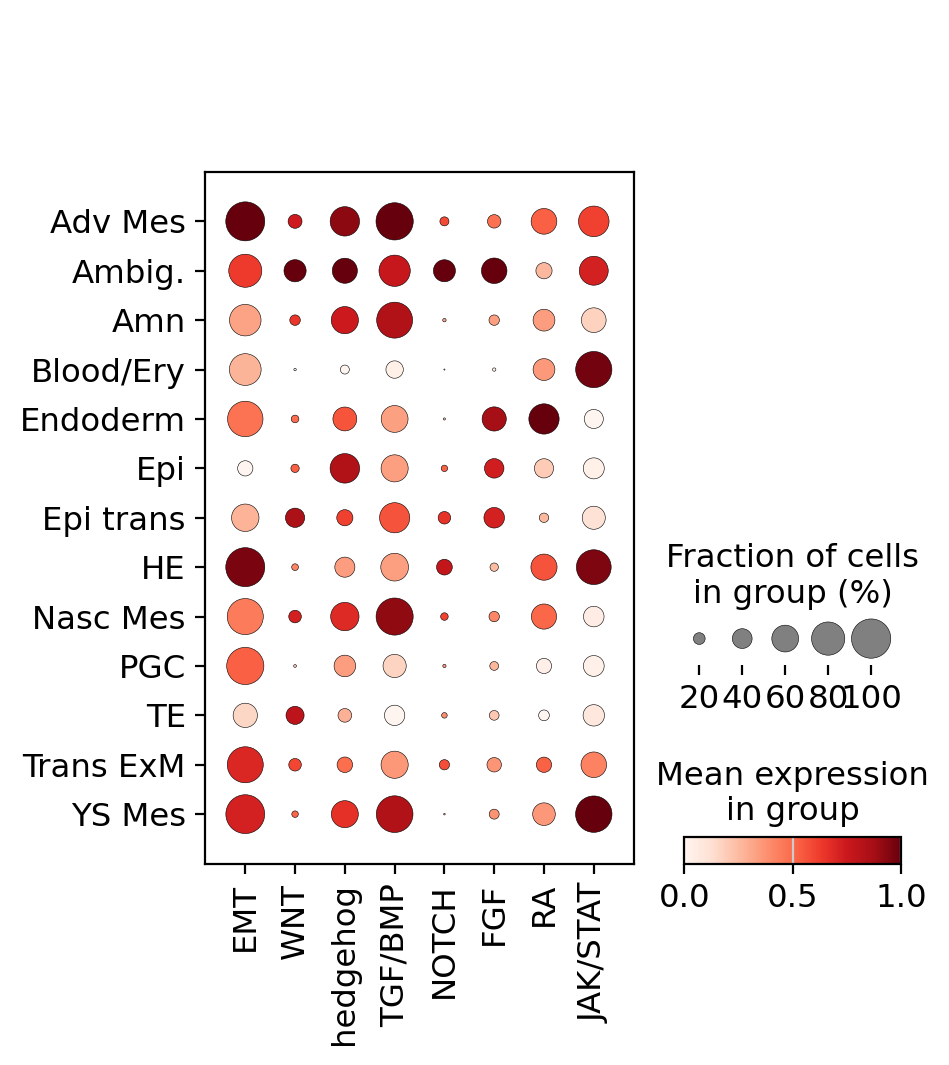

In [ ]:
scores = [
    "EMT",
    "WNT",
    "hedgehog",
    "TGF/BMP",
    "NOTCH",
    "FGF",
    "RA",
    "JAK/STAT",
]

dp = sc.pl.dotplot(
    adata,
    var_names=scores,
    groupby="CellType_short",
    standard_scale="var",
    cmap="Reds",
    return_fig=True,
    show=False,
)

dp.savefig(
    fig_dir / "dotplot_pathwayscore.pdf",
    bbox_inches="tight",
)